## Coral Reef Bleaching Analysis

#### Questions for analysis:

1. Which countries have the highest average bleaching percentages?
2. How does the variability (standard deviation) of bleaching percentages compare across different countries?
3. What is the distribution of reef depths in our dataset?
4. How has the bleaching percentage changed over the years from 2007 to 2017 in the top countries?
5. Which reefs have the highest bleaching percentages?

In [19]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt

In [35]:
def load_data(filepath):
    return pd.read_csv('Reef Check Data Raw.csv')

In [36]:
def data_inspection(data):
    # Initial inspection
    print("Info:", data.info())
    print("DataFrame Shape:", data.shape)
    print("Num of missing values:", data.isnull().sum())
    print("Num of duplicate values:", data.duplicated().sum())

In [43]:
def cleaner(data, citical_cols):
    data = data.dropna(subset=critical_cols)
    data = data.drop_duplicates()    
    return data

In [40]:
def standardize_data(data):
    # Standardizing our data
    data['Longitude'] = data['Longitude Degrees'].astype(str) + " " + data['Longitude Minutes'].astype(str) + " " \
                        + data['Longitude Seconds'].astype(str) + " " + data['Longitude Cardinal Direction']
    
    data['Latitude'] = data['Latitude Degrees'].astype(str) + " " + data['Latitude Minutes'].astype(str) + " " \
                        + data['Latitude Seconds'].astype(str) + " " + data['Latitude Cardinal Direction']

    data['Depth'] = pd.to_numeric(data['Depth'], errors='coerce')
    data['Depth'].fillna(data['Depth'].mean(), inplace=True)

    data['Year'] = pd.to_numeric(data['Year'], errors='coerce')

    data['Year'].dropna(inplace=True)

    def extract_bleaching(row):
        return row["S1"] + row["S2"] + row["S3"] + row["S4"]

    # Data Featuring
    data['Bleaching_Percentage'] = data.apply(extract_bleaching, axis=1)
    data['Bleaching_Percentage'].fillna(data['Bleaching_Percentage'].mean(), inplace=True)
    data['Bleaching_Percentage'] = data['Bleaching_Percentage'].apply(lambda x: min(x, 100)) # cap at 100%

    return data

In [41]:
def filter_and_group(data):
    # Filtering and grouping
    data_reef_depth = data[data['Depth'] > 5]
    data_high_bleaching = data[data['Bleaching_Percentage']>50]
    data_years = data[data['Year'] >= 2000]
    group_by_country = data.groupby('Country')['Bleaching_Percentage'].aggregate(['mean', 'std']).sort_values(by='mean', ascending=False).head(15)
    pivot = data.pivot_table(values="Bleaching_Percentage", index="Country", columns="Year", aggfunc="mean")
    pivot = pivot.loc[:, 2007:2017]
    top_countries = pivot.mean(axis=1).sort_values(ascending=False).head(15).index
    pivot = pivot.loc[top_countries]
    print(pivot)
    return data_high_bleaching, data_reef_depth, data_years, pivot, group_by_country

In [42]:
def visualization(group_by_country, data_reef_depth, pivot, data_high_bleaching):
    # Data Visualization
    fig, axs = plt.subplots(2, 2, figsize=(18, 12))
    
    # Which countries have the highest average bleaching percentages?
    group_by_country['mean'].plot(kind='bar', ax=axs[0,0], color='purple')
    axs[0, 0].set_title("Average Bleaching By Country")
    axs[0, 0].set_ylabel("Average Bleaching")
    axs[0, 0].set_xlabel("Country")
    axs[0, 0].errorbar(group_by_country.index, group_by_country['mean'], yerr = group_by_country['std'], fmt='none', c='black', 
                       capsize=5, label='Standard Deviation')
    axs[0, 0].legend()
    
    # Number of Reefs by Depth
    depth_count = data_reef_depth["Depth"].astype(int).value_counts().sort_index()
    axs[0,1].scatter(depth_count.index, depth_count.values, color='red')
    axs[0,1].set_title("Number of reefs by depth")
    axs[0,1].set_xlabel("Depth")
    axs[0,1].set_ylabel("Count")
    
    # Bleaching percentage by country (2007 - 2017)
    pivot.plot(kind='bar', ax=axs[1,0], width=0.8)
    axs[1,0].set_title('Bleaching By Year and Country')
    axs[1,0].set_ylabel('Bleaching Percentage')
    
    # Top 15 places for bleaching
    data_high_bleaching.head(15).set_index('Reef Name')['Bleaching_Percentage'].plot(kind='bar', ax=axs[1,1])
    axs[1,1].set_title('Top 15 Bleaching Locations')
    axs[1,1].set_ylabel('Percentage')
    
    plt.tight_layout()
    plt.show()

In [44]:
critical_cols = ["Reef ID", "Reef Name", "Longitude Degrees", "Latitude Degrees", "Country", "Depth", "Organism Code", "S1", "S2", "S3", "S4"]

In [45]:
def main():
    data = load_data('Reef Check Data Raw.csv')

    data_inspection(data)
    critical_cols = ["Reef ID", "Reef Name", "Longitude Degrees", "Latitude Degrees", "Country", "Depth", "Organism Code", "S1", "S2", "S3", "S4"]
    data = cleaner(data, critical_cols)
    data = standardize_data(data)
    data_high_bleaching, data_reef_depth, data_years, pivot, group_by_country = filter_and_group(data)
    visualization(group_by_country, data_reef_depth, pivot, data_high_bleaching)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18211 entries, 0 to 18210
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Reef ID                       18211 non-null  object 
 1   Reef Name                     18211 non-null  object 
 2   Longitude Degrees             18165 non-null  float64
 3   Longitude Minutes             18165 non-null  float64
 4   Longitude Seconds             18161 non-null  float64
 5   Longitude Cardinal Direction  18179 non-null  object 
 6   Latitude Degrees              18165 non-null  float64
 7   Latitude Minutes              18165 non-null  float64
 8   Latitude Seconds              18165 non-null  float64
 9   Latitude Cardinal Direction   18179 non-null  object 
 10  Ocean                         18171 non-null  object 
 11  Country                       18211 non-null  object 
 12  State/Province/Island         16258 non-null  object 
 13  C

/tmp/ipykernel_9718/2581712818.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Depth'].fillna(data['Depth'].mean(), inplace=True)
/tmp/ipykernel_9718/2581712818.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

Year                      2007       2008       2009       2010       2011  \
Country                                                                      
Colombia             61.750000        NaN        NaN        NaN        NaN   
Trinidad & Tobago    29.750000        NaN  78.750000        NaN        NaN   
Tonga                      NaN        NaN        NaN        NaN        NaN   
Grenada                    NaN        NaN        NaN        NaN        NaN   
Costa Rica                 NaN        NaN  30.333333  39.437500        NaN   
Bahamas              28.000000  26.812500  26.250000  24.166667   7.562500   
Martinique                 NaN        NaN  13.500000   5.000000  10.500000   
Australia             7.247979   4.739872  25.561644  30.094340  22.892308   
Maldives             36.433333   8.029412  22.343750  23.750000  30.305556   
Sudan                      NaN        NaN  25.812500        NaN        NaN   
Thailand             22.687500   1.866667   0.722222  65.807692 

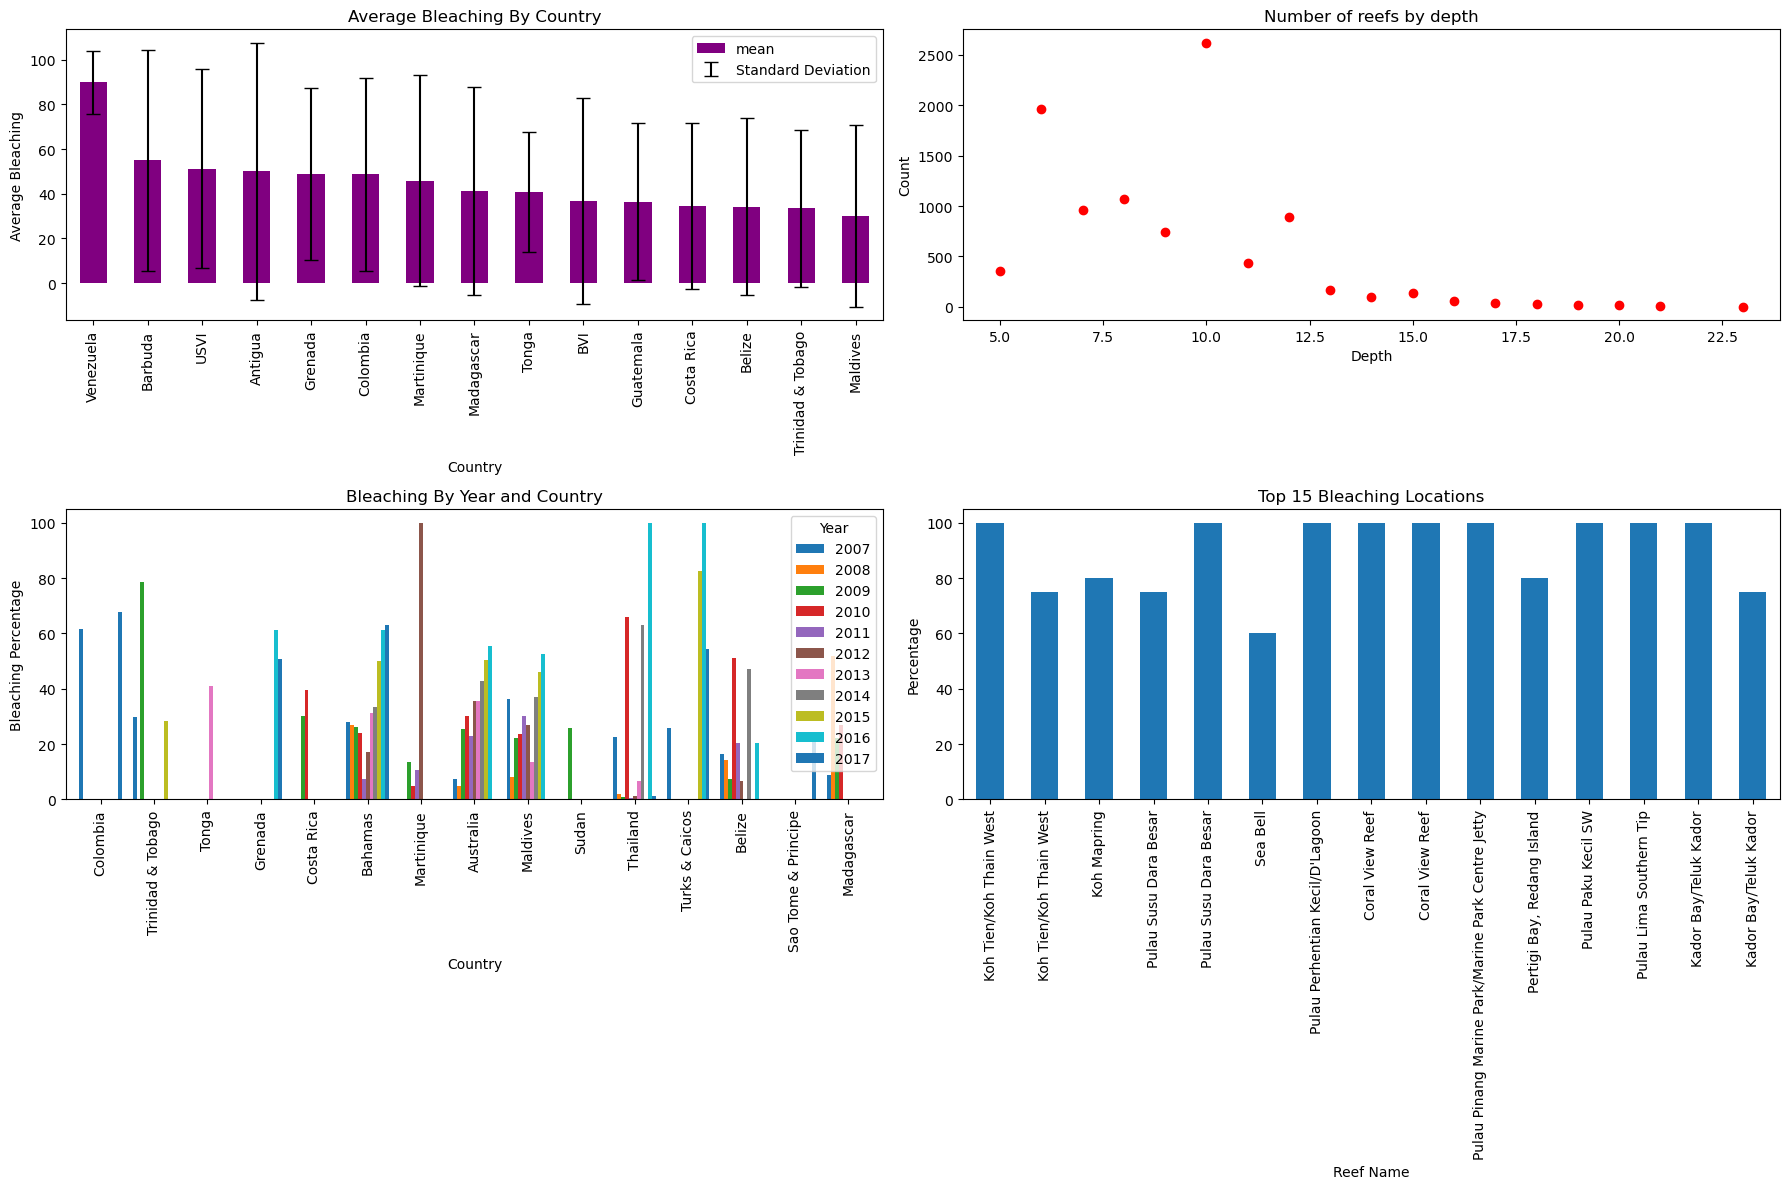

In [46]:
if __name__ in '__main__':
    main()